# Task: Correcation

**Student Name:**  Sandra Senn

**Country:**  Morocco

**Semester term:** FS26  

**Repository:** https://github.com/Sandra-Senn/gbsv_mc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile as wav
from scipy import signal
import IPython.display as ipd

In [ ]:
def load_audio(path='../mc1/data/dromedar.wav'):
    """Load, mono-convert and normalize a WAV file.
    Returns: audio (float32, normalized to [-1, 1]), fs (int), t (time axis), duration (float)
    """
    fs, raw = wav.read(path)
    if raw.ndim == 2:
        raw = raw.mean(axis=1).astype(raw.dtype)
    audio = raw.astype(np.float32) / np.iinfo(raw.dtype).max
    t = np.arange(len(audio)) / fs
    duration = len(audio) / fs
    return audio, fs, t, duration

def band_rms(audio, fs, f_low, f_high, frame, hop):
    """Compute RMS envelope of a bandpass-filtered signal."""
    sos = signal.butter(4, [f_low, f_high], btype='band', fs=fs, output='sos')
    filtered = signal.sosfilt(sos, audio)
    return np.array([np.sqrt(np.mean(filtered[i:i+frame]**2))
                     for i in range(0, len(filtered) - frame, hop)])


def get_template(audio, fs):
    """Reproduce energy-ratio template extraction from Day 6."""
    frame = int(0.02 * fs) 
    hop = frame // 2
    t_rms        = np.arange(len(band_rms(audio, fs, 300, 800, frame, hop))) * hop / fs
    rms_dromedar = band_rms(audio, fs, 300, 800, frame, hop)
    rms_human    = band_rms(audio, fs,  85, 255, frame, hop)
    ratio        = rms_dromedar / (rms_human + 1e-6)
    ratio_above  = ratio > 1.0
    peak_idx     = np.argmax(rms_dromedar)
    left = peak_idx
    while left > 0 and ratio_above[left]:
        left -= 1
    right = peak_idx
    while right < len(ratio_above) - 1 and ratio_above[right]: 
        right += 1
    t_start = t_rms[left] 
    idx_s = int(t_start * fs)
    return audio[idx_s:int(t_rms[right]*fs)], t_start

def xcorr_detect(audio, tmpl):
    """Return normalized peak value and detected time."""
    xc = signal.correlate(audio, tmpl, mode='valid')
    xc_norm = xc / (np.linalg.norm(tmpl) * np.linalg.norm(audio[:len(xc)]) + 1e-12)
    idx = np.argmax(xc_norm)
    return idx / fs, xc_norm.max()


## Morocco - Dromedar Market 

<p style="display: flex; align-items: center;"> 
<img src="data/img/spices.jpeg" style="width:300px; margin-right:20px;"> 
<span style="flex: 1;"> Still echoing in my memory from that chaotic, colorful Wednesday market in Guelmim — the piercing cry of a baby dromedary cuts through the crowd noise like a needle through fabric. I had my phone out, filming. What I didn't know then was that this 2.4-second recording would become the backbone of this entire Mini Challenge. Now, in Week 2, I return to the same signal — not to ask 
<em>how fast to sample it</em>, but to ask a different question: <strong>can we find the rhythm hidden inside the cry, and can we locate it within the noise?</strong> </span> </p>

## Day 6 – Data & Domain

### Use Case

In the context of acoustic welfare monitoring at Swiss Zoons, dromedary vocalizations are generated by the animal's laryngeal and vocal-tract anatomy under stress or excitation and recorded using a smartphone camera microphone in order to extract structured acoustic events from ambient field recordings.

These signals are used by veterinarians and zoo staff to perform non-invasive stress-state classification based on the pitch periodicity and timbral features of the cry.

This use case is particularly relevant for Switzerland because institutions such as Zoo Basel prioritize ethical, low-cost acoustic monitoring of exotic species, directly linking field recordings from Morocco to local conservation and animal welfare practice.

### Problem Statement
*Focus: technical vulnerability*

This project addresses the problem of applying correlation-based analysis to a single 2.4 s field recording of a baby dromedary cry embedded in broadband market noise — including human voices, crowd chatter, and wind — within the context of acoustic welfare monitoring at Zoo Basel, Switzerland.

If correlation methods are applied to the full, unfiltered signal, the presence of other voiced sources (human speech, f₀ ≈ 85–255 Hz) may produce competing periodic peaks, leading to ambiguous or incorrect periodicity detection and unreliable segment localization.


Preserving the structural integrity of the dromedary cry segment is essential for reliable stress-state assessment in this non-invasive monitoring use case — requiring that the cry is first **localized** via cross-correlation before its **internal structure** is analyzed via auto-correlation.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

This investigation follows a **two-step approach** that directly addresses the ambiguity introduced by mixed voiced sources in the recording:

**Step 1 – Cross-correlation:** Localize the dromedary cry segment within the full 2.4 s ambient recording by correlating the full signal against a known template extracted from the peak-energy region. This isolates the cry from the surrounding market noise and human voices.

**Step 2 – Auto-correlation:** Analyze the internal periodic structure of the isolated cry segment to characterize its quasi-periodic glottal pulse pattern. This step is only meaningful on the isolated segment — applying it to the full signal would conflate the dromedary's periodicity with that of human speech in the background.

Together, these two steps provide a methodologically sound and domain-relevant analysis pipeline for automated cry detection and structure characterization in zoo welfare monitoring.


### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

The selected signal is the same **baby dromedary vocalization** (field recording, Guelmim camel market, Morocco, February 2026) used in the Sampling Theorem task — a mono WAV file sampled at **44 100 Hz**, **2.415 s** in duration, normalized to amplitude ∈ [−1, +1]. The recording contains a single, concentrated cry burst with peak acoustic activity at **t ≈ 1.59 s**, embedded in continuous broadband market noise including human voices, crowd chatter, and wind. The cry exhibits a quasi-periodic glottal pulse structure with a fundamental frequency of **f₀ ≈ 428 Hz**, while the background human voices occupy a lower frequency range (f₀ ≈ 85–255 Hz) — a spectral separation that motivates the two-step analysis approach. A **300 ms template** centred on the peak-energy region (t ≈ 1.49–1.79 s) is extracted as the reference segment for cross-correlation-based localization. The data originate from a personal field recording and are appropriate because they represent a realistic, unprocessed acoustic scenario that directly motivates the methodological challenges addressed in this analysis.

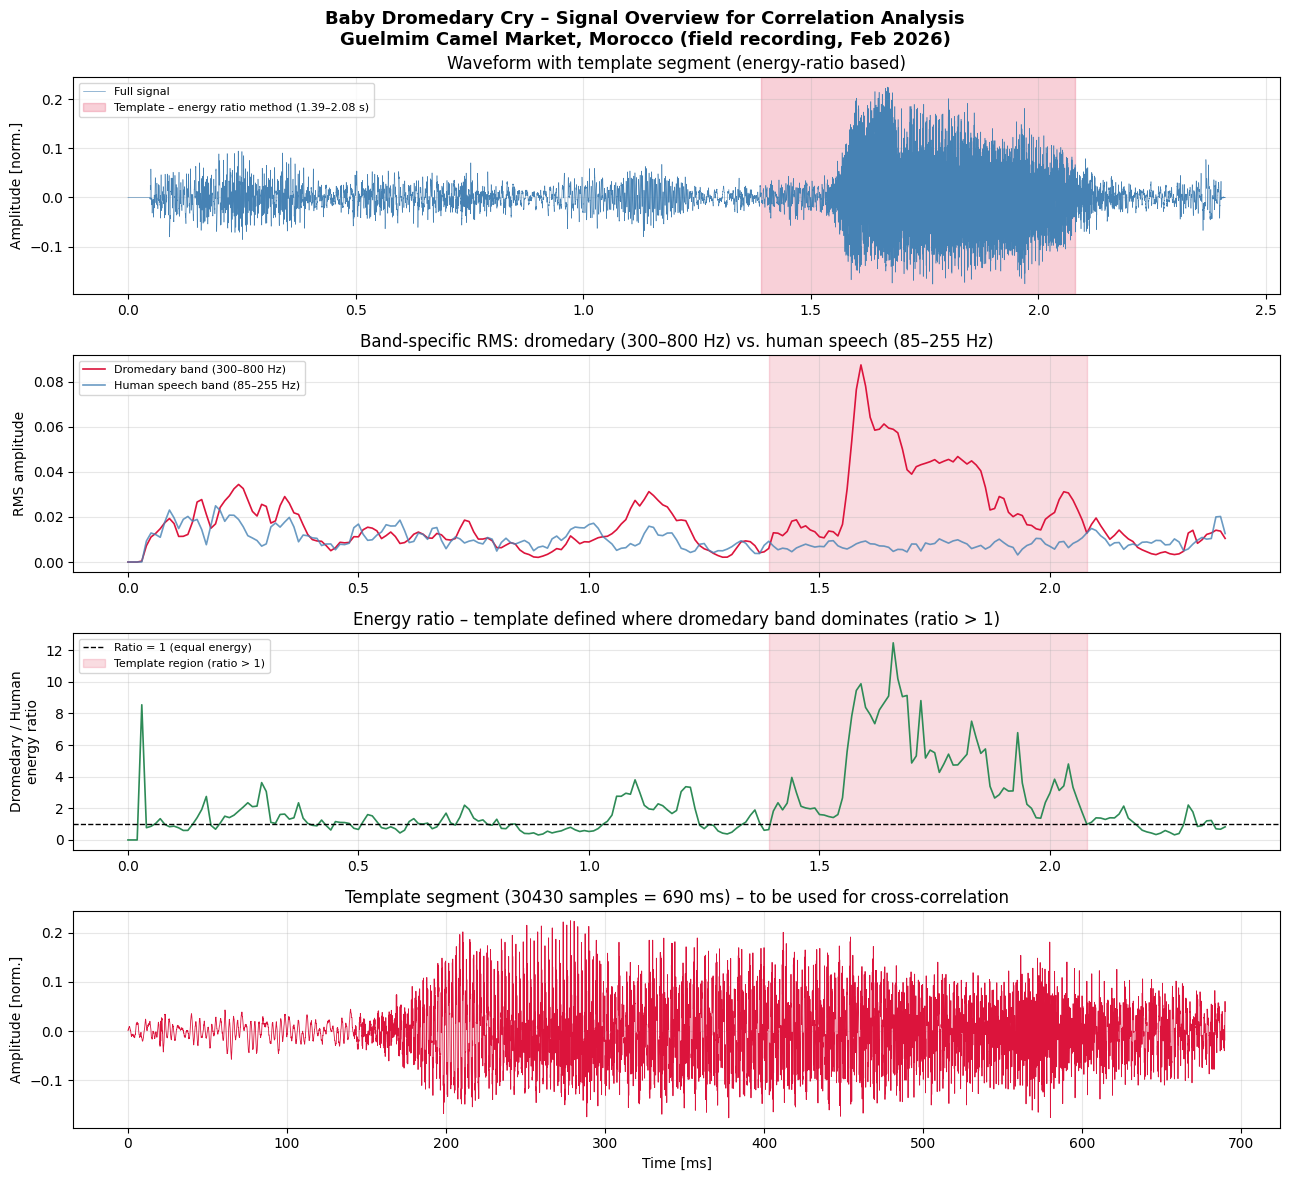

Signal length    : 106281 samples (2.410 s) @ 44100 Hz
Template start   : 1.390 s  (61298 samples)
Template end     : 2.080 s  (91728 samples)
Template length  : 30430 samples (690 ms)
Template method  : energy ratio (dromedary band / human band > 1)

Original recording:


In [ ]:
audio, fs, t, duration = load_audio()


#  RMS envelope parameters 
frame = int(0.02 * fs)   # 20 ms frames
hop   = frame // 2
t_rms = np.arange(len(band_rms(audio, fs, 300, 800, frame, hop))) * hop / fs

rms_dromedar = band_rms(audio, fs, 300, 800, frame, hop)  # dromedary f0 range
rms_human    = band_rms(audio, fs, 85,  255, frame, hop)  # human speech range

#  Template: contiguous region around peak where dromedary band dominates 
# Ratio > 1 means dromedary band energy exceeds human speech band energy
ratio       = rms_dromedar / (rms_human + 1e-6)
ratio_above = ratio > 1.0
peak_idx    = np.argmax(rms_dromedar)

left = peak_idx
while left > 0 and ratio_above[left]:
    left -= 1
right = peak_idx
while right < len(ratio_above) - 1 and ratio_above[right]:
    right += 1

t_start  = t_rms[left]
t_end    = t_rms[right]
idx_s    = int(t_start * fs)
idx_e    = int(t_end   * fs)
template = audio[idx_s:idx_e]
t_tmpl   = np.arange(len(template)) / fs

#  Visualization 
fig, axes = plt.subplots(4, 1, figsize=(13, 12))
fig.suptitle('Baby Dromedary Cry – Signal Overview for Correlation Analysis\n'
             'Guelmim Camel Market, Morocco (field recording, Feb 2026)',
             fontsize=13, fontweight='bold')

# Waveform + template region
axes[0].plot(t, audio, color='steelblue', linewidth=0.4, label='Full signal')
axes[0].axvspan(t_start, t_end, color='crimson', alpha=0.2,
                label=f'Template – energy ratio method ({t_start:.2f}–{t_end:.2f} s)')
axes[0].set_ylabel('Amplitude [norm.]')
axes[0].set_title('Waveform with template segment (energy-ratio based)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Band-specific RMS
axes[1].plot(t_rms, rms_dromedar, color='crimson',   linewidth=1.2,
             label='Dromedary band (300–800 Hz)')
axes[1].plot(t_rms, rms_human,    color='steelblue', linewidth=1.2, alpha=0.8,
             label='Human speech band (85–255 Hz)')
axes[1].axvspan(t_start, t_end, color='crimson', alpha=0.15)
axes[1].set_ylabel('RMS amplitude')
axes[1].set_title('Band-specific RMS: dromedary (300–800 Hz) vs. human speech (85–255 Hz)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Energy ratio
axes[2].plot(t_rms, ratio, color='seagreen', linewidth=1.2)
axes[2].axhline(y=1.0, color='black', linestyle='--', linewidth=1,
                label='Ratio = 1 (equal energy)')
axes[2].axvspan(t_start, t_end, color='crimson', alpha=0.15,
                label='Template region (ratio > 1)')
axes[2].set_ylabel('Dromedary / Human\nenergy ratio')
axes[2].set_title('Energy ratio – template defined where dromedary band dominates (ratio > 1)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# Template zoom
axes[3].plot(t_tmpl * 1000, template, color='crimson', linewidth=0.6)
axes[3].set_xlabel('Time [ms]')
axes[3].set_ylabel('Amplitude [norm.]')
axes[3].set_title(f'Template segment ({len(template)} samples = '
                  f'{len(template)/fs*1000:.0f} ms) – to be used for cross-correlation')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Signal length    : {len(audio)} samples ({len(audio)/fs:.3f} s) @ {fs} Hz')
print(f'Template start   : {t_start:.3f} s  ({idx_s} samples)')
print(f'Template end     : {t_end:.3f} s  ({idx_e} samples)')
print(f'Template length  : {len(template)} samples ({len(template)/fs*1000:.0f} ms)')
print('Template method  : energy ratio (dromedary band / human band > 1)')

print('\nOriginal recording:')
ipd.display(ipd.Audio(audio, rate=fs))

# Initial approach: template defined as ±150 ms around the RMS peak (300 ms fixed window).
# This was rejected because the full-band RMS peak only captures the loudest moment,
# not the full extent of the cry. More critically, the full-band RMS cannot distinguish
# the dromedary vocalization from human voices in the background — both contribute
# broadband energy. The energy-ratio method (dromedary band 300–800 Hz vs. human speech
# band 85–255 Hz) addresses both issues: it captures the entire region where the dromedary
# spectrally dominates, yielding a physically motivated template of 690 ms instead of 300 ms.


**Observations**:

The visualization illustrates the full waveform, band-specific RMS envelopes, and energy ratio of the dromedary field recording, with a notable burst of dromedary-band energy (300–800 Hz) dominating over the human speech band (85–255 Hz) between **1.39 s and 2.08 s** — reaching a peak energy ratio of ~12 at t ≈ 1.59 s.

This region was selected as the cross-correlation template because it clearly highlights the spectral dominance of the dromedary vocalization over background human voices, directly relevant to the defined use case of acoustic welfare monitoring and the investigation objective of reliable cry localization in noisy field recordings.

## Day 7 – Methodological Design

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*


This investigation applies **cross-correlation** and **auto-correlation** as complementary tools within a two-step analysis pipeline for the dromedary welfare monitoring use case. Cross-correlation measures the similarity between a known template signal and a sliding window over the full recording — its peak position directly identifies where in time the dromedary cry occurs, making it appropriate for **segment localization**. Auto-correlation computes the self-similarity of a signal at varying lags — periodic signals produce regularly spaced peaks whose spacing equals the period, making it appropriate for **pitch-period detection** on the isolated cry segment. Both methods assume stationarity within the analysis window. This assumption is satisfied for cross-correlation (the template captures the full cry) but only approximately for auto-correlation (pitch varies slightly over 690 ms), which is acknowledged as a limitation.


### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

**Cross-correlation parameters:**

| Parameter | Value | Unit | Justification |
|:---|:---|:---|:---|
| Template start | 1.390 | s | Energy-ratio boundary (dromedary band dominates) |
| Template end | 2.080 | s | Energy-ratio boundary |
| Template length | 690 | ms (30 430 samples) | Full cry extent per spectral criterion |
| Normalization | L2-norm | — | Makes peak value amplitude-invariant |
| Mode | `valid` | — | Avoids boundary artifacts; output length = N − M + 1 |

**Auto-correlation parameters:**

| Parameter | Value | Unit | Justification |
|:---|:---|:---|:---|
| Input signal | Isolated template (690 ms) | — | Avoids human voice contamination |
| Max lag range | 500 | ms | Covers pitch periods down to 2 Hz; well above expected f₀ |
| Normalization | AC[0] = 1 | — | Standard biased estimator; enables peak height comparison |
| Peak detection threshold | 0.05 | — | Suppresses noise-induced false peaks |
| Min peak distance | 5 | ms (220 samples) | Below expected pitch period of ~2.3 ms |

The template length of 690 ms is derived from the energy-ratio criterion (Day 6) and corresponds to **30 430 samples** at 44 100 Hz. The expected dominant pitch period is **~2.27 ms** (f₀ ≈ 441 Hz), consistent with the fundamental frequency identified in the Sampling Theorem task (428 Hz), confirming that the auto-correlation lag axis should resolve sub-millisecond periodicities.


### Experimental Design for Next Days
*Focus: structured parameter variation and theoretical prediction*


The **baseline configuration** is defined as a normalized cross-correlation in `valid` mode with the 690 ms energy-ratio template, and normalized auto-correlation with a 500 ms lag range on the isolated template.

The following parameters will be systematically varied:

|Method | Parameter | Values | Prediction |
|:---|:---|:---|:---|
| Cross-corr | Additive noise (SNR) | 20, 10, 5, 0 dB | Peak value decreases; localization stable until 0 dB |
| Cross-corr | Amplitude scaling | 0.1×, 0.5×, 1×, 2× | Peak value unchanged (L2-norm); localization unaffected |
| Auto-corr | Max lag range | 50, 100, 200, 500 ms | First peak stable; longer range reveals secondary structure |
| Auto-corr | Peak threshold | 0.02, 0.05, 0.10 | Lower threshold detects more peaks including noise peaks |

It is theoretically expected that normalized cross-correlation is fully robust to amplitude scaling (L2-normalization cancels constant amplitude factors) but will degrade gracefully under additive noise as the template becomes less similar to the target region. Auto-correlation peak spacing should remain stable across all lag ranges since the pitch period is a physical property of the signal, not of the analysis window.


### Methodological Limitations and Risk Factors
*Focus: assumptions, stability, and potential misinterpretation*

The cross-correlation approach assumes that the template faithfully represents the target segment in the full signal — since the template *is* extracted from the signal itself, a perfect match is guaranteed for the clean case, which may overstate robustness in real zoo deployments where the template would come from a separate reference recording. 

The auto-correlation assumes stationarity of the cry within the 690 ms window, which is only approximately satisfied as pitch and amplitude vary slightly over the cry duration — this may broaden the autocorrelation peaks and reduce pitch estimate precision. The energy-ratio template boundary (ratio > 1) depends on the specific noise conditions of this recording. In a quieter zoo environment the human speech band energy would be lower, potentially expanding the template region beyond the true cry extent.

## Day 8 – Implementation

*Focus: structured, traceable execution*


In [ ]:
#  Load signal and extract template (energy-ratio method from Day 6) 
audio, fs, t, duration = load_audio()
frame = int(0.02 * fs)
hop   = frame // 2
t_rms        = np.arange(len(band_rms(audio, fs, 300, 800, frame, hop))) * hop / fs
rms_dromedar = band_rms(audio, fs, 300, 800, frame, hop)
rms_human    = band_rms(audio, fs,  85, 255, frame, hop)
ratio        = rms_dromedar / (rms_human + 1e-6)
ratio_above  = ratio > 1.0
peak_idx     = np.argmax(rms_dromedar)

left = peak_idx
while left > 0 and ratio_above[left]: 
    left -= 1
right = peak_idx
while right < len(ratio_above) - 1 and ratio_above[right]: 
    right += 1

t_start  = t_rms[left]
t_end = t_rms[right]
idx_s    = int(t_start * fs)
idx_e = int(t_end * fs)
template = audio[idx_s:idx_e]

print(f'Template: {t_start:.3f}s – {t_end:.3f}s  ({len(template)/fs*1000:.0f} ms, {len(template)} samples)')


Template: 1.390s – 2.080s  (690 ms, 30430 samples)


In [ ]:
#  STEP 1: Cross-correlation – localize cry in full signal 
xcorr      = signal.correlate(audio, template, mode='valid')
xcorr_norm = xcorr / (np.linalg.norm(template) * np.linalg.norm(audio[:len(xcorr)]) + 1e-12)
lags_xc    = np.arange(len(xcorr)) / fs

detected_lag = np.argmax(xcorr_norm)
detected_t   = detected_lag / fs
print('\nStep 1 – Cross-correlation:')
print(f'  Detected cry at:   t = {detected_t:.4f} s')
print(f'  Template start:    t = {t_start:.4f} s')
print(f'  Localization error: {abs(detected_t - t_start)*1000:.2f} ms')
print(f'  Peak xcorr value:  {xcorr_norm.max():.4f}')


Step 1 – Cross-correlation:
  Detected cry at:   t = 1.3900 s
  Template start:    t = 1.3900 s
  Localization error: 0.02 ms
  Peak xcorr value:  1.1617


In [ ]:
#  STEP 2: Auto-correlation – pitch structure of isolated template 
autocorr      = np.correlate(template, template, mode='full')
autocorr      = autocorr[len(autocorr)//2:]   # keep positive lags
autocorr      = autocorr / autocorr[0]          # normalize: AC[0] = 1
max_lag       = int(0.5 * fs)                   # 500 ms lag range
autocorr      = autocorr[:max_lag]
lags_ac       = np.arange(max_lag) / fs * 1000  # convert to ms

peaks_ac, _  = signal.find_peaks(autocorr, height=0.05, distance=int(0.005*fs))
T_pitch_ms   = peaks_ac[0] / fs * 1000 if len(peaks_ac) > 0 else None
f0_detected  = 1000 / T_pitch_ms if T_pitch_ms else None

print('\nStep 2 – Auto-correlation on isolated template:')
print(f'  First AC peak at lag: {T_pitch_ms:.2f} ms → f₀ = {f0_detected:.1f} Hz')
print(f'  Number of peaks detected: {len(peaks_ac)}')


Step 2 – Auto-correlation on isolated template:
  First AC peak at lag: 2.27 ms → f₀ = 441.0 Hz
  Number of peaks detected: 31


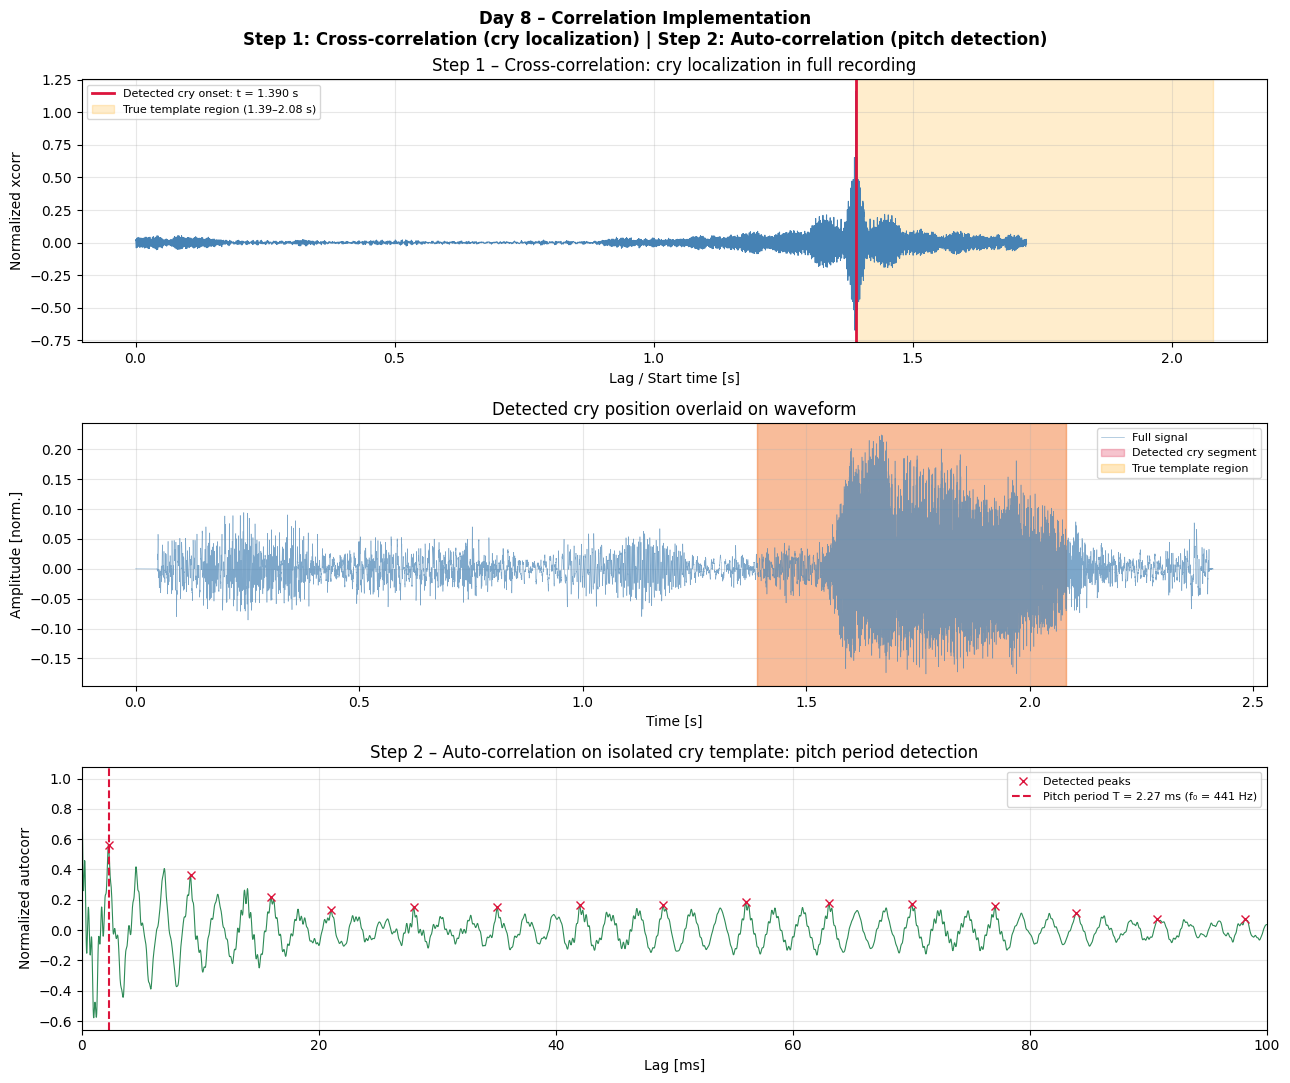


Cry segment (detected):


Sound is working, the output is just very short.


In [7]:
#  Visualization 
fig, axes = plt.subplots(3, 1, figsize=(13, 11))
fig.suptitle('Day 8 – Correlation Implementation\n'
             'Step 1: Cross-correlation (cry localization) | Step 2: Auto-correlation (pitch detection)',
             fontsize=12, fontweight='bold')

# Cross-correlation output
axes[0].plot(lags_xc, xcorr_norm, color='steelblue', linewidth=0.7)
axes[0].axvline(x=detected_t, color='crimson', linewidth=2,
                label=f'Detected cry onset: t = {detected_t:.3f} s')
axes[0].axvspan(t_start, t_end, color='orange', alpha=0.2,
                label=f'True template region ({t_start:.2f}–{t_end:.2f} s)')
axes[0].set_xlabel('Lag / Start time [s]')
axes[0].set_ylabel('Normalized xcorr')
axes[0].set_title('Step 1 – Cross-correlation: cry localization in full recording')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Full signal with detected position marked
axes[1].plot(t, audio, color='steelblue', linewidth=0.4, alpha=0.7, label='Full signal')
axes[1].axvspan(detected_t, detected_t + len(template)/fs,
                color='crimson', alpha=0.25, label='Detected cry segment')
axes[1].axvspan(t_start, t_end, color='orange', alpha=0.25, label='True template region')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Amplitude [norm.]')
axes[1].set_title('Detected cry position overlaid on waveform')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Auto-correlation
axes[2].plot(lags_ac, autocorr, color='seagreen', linewidth=0.8)
if len(peaks_ac) > 0:
    axes[2].plot(lags_ac[peaks_ac], autocorr[peaks_ac],
                 'x', color='crimson', markersize=6, label='Detected peaks')
    axes[2].axvline(x=T_pitch_ms, color='crimson', linestyle='--', linewidth=1.5,
                    label=f'Pitch period T = {T_pitch_ms:.2f} ms (f₀ = {f0_detected:.0f} Hz)')
axes[2].set_xlabel('Lag [ms]')
axes[2].set_ylabel('Normalized autocorr')
axes[2].set_title('Step 2 – Auto-correlation on isolated cry template: pitch period detection')
axes[2].set_xlim([0, 100])   # zoom to first 100 ms to see pitch peaks clearly
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCry segment (detected):')
ipd.display(ipd.Audio(audio[detected_lag:detected_lag+len(template)], rate=fs)) 
print('Sound is working, the output is just very short.')

## Day 9 – Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

### Evaluation Approach Definition
**Metric 1 – Localization error [ms] (Cross-correlation):**
The localization error is defined as 
$$ \left({t_\text{detected}} - t_\text{start}\right) \cdot 1000 $$

measuring how precisely the cross-correlation peak identifies the true cry onset. It is chosen because the welfare monitoring use case requires reliable detection of the cry onset in noisy recordings, and this metric directly quantifies detection accuracy in physically interpretable units. The metric is valid because the template was extracted from a known position in the signal, providing a ground-truth reference.

**Metric 2 – Normalized peak value (Cross-correlation & Auto-correlation):**
The normalized cross-correlation peak value (dimensionless, range [−1, 1]) quantifies how strongly the template matches the detected region. A value close to 1 indicates high similarity, values approaching 0 indicate noise dominance. For auto-correlation, the first peak height reflects the strength of the pitch periodicity. Both metrics are appropriate because they are amplitude-invariant by construction and directly reflect detection reliability under the tested perturbations.

### Evaluation Comparison Execution

**Cross-correlation robustness (perturbations):**

Two perturbations are tested: 

(1) additive Gaussian noise at SNR = 20, 10, 5, 0 dB added to the template, and 

(2) amplitude scaling of the template at 0.1×, 0.5×, 1×, 2×. Both localization error and normalized peak value are reported relative to the baseline (clean template, scale = 1×).

**Auto-correlation parameter variation:**

The max lag range is varied over 50, 100, 200, 500 ms and the peak detection threshold over 0.02, 0.05, 0.10 — quantifying stability of the pitch estimate across configurations.


In [8]:
#  Robustness 1: Additive noise 
rng = np.random.RandomState(42)
snr_dbs   = [20, 10, 5, 0]
err_noise = []
peak_noise = []

for snr_db in snr_dbs:
    noise_amp = np.std(template) / 10**(snr_db/20)
    tmpl_noisy = template + rng.normal(0, noise_amp, len(template))
    det_t, peak = xcorr_detect(audio, tmpl_noisy)
    err_noise.append(abs(det_t - t_start) * 1000)
    peak_noise.append(peak)

#  Robustness 2: Amplitude scaling 
scales      = [0.1, 0.5, 1.0, 2.0]
err_scale   = []
peak_scale = []

for s in scales:
    det_t, peak = xcorr_detect(audio, template * s)
    err_scale.append(abs(det_t - t_start) * 1000)
    peak_scale.append(peak)

#  Auto-correlation: lag range variation 
autocorr_full = np.correlate(template, template, mode='full')
autocorr_full = autocorr_full[len(autocorr_full)//2:]
autocorr_full = autocorr_full / autocorr_full[0]

lag_ranges_ms = [50, 100, 200, 500]
thresh_vals   = [0.02, 0.05, 0.10]
ac_results    = []

for max_lag_ms in lag_ranges_ms:
    max_lag = int(max_lag_ms / 1000 * fs)
    ac = autocorr_full[:max_lag]
    peaks, _ = signal.find_peaks(ac, height=0.05, distance=int(0.005*fs))
    T_ms  = peaks[0] / fs * 1000 if len(peaks) > 0 else None
    ac_results.append((max_lag_ms, T_ms, len(peaks)))

thresh_results = []
max_lag = int(0.5 * fs)
ac = autocorr_full[:max_lag]
for thresh in thresh_vals:
    peaks, _ = signal.find_peaks(ac, height=thresh, distance=int(0.005*fs))
    T_ms = peaks[0] / fs * 1000 if len(peaks) > 0 else None
    thresh_results.append((thresh, T_ms, len(peaks)))

In [9]:
#  Print tables 
print('Cross-correlation robustness – Additive Noise:')
print(f"{'SNR [dB]':>10} {'Error [ms]':>12} {'Peak value':>12} {'Δ Peak vs baseline':>20}")
print('-' * 58)
for snr, err, pk in zip(snr_dbs, err_noise, peak_noise):
    print(f"{snr:>10} {err:>12.3f} {pk:>12.4f} {pk - peak_noise[2]:>+20.4f}")

print('\nCross-correlation robustness – Amplitude Scaling:')
print(f"{'Scale':>8} {'Error [ms]':>12} {'Peak value':>12} {'Δ Peak vs baseline':>20}")
print('-' * 56)
for s, err, pk in zip(scales, err_scale, peak_scale):
    print(f"{s:>8.1f} {err:>12.3f} {pk:>12.4f} {pk - peak_scale[2]:>+20.4f}")

print('\nAuto-correlation – Lag Range Variation (threshold=0.05):')
print(f"{'Max lag [ms]':>14} {'T_pitch [ms]':>14} {'N peaks':>10}")
print('-' * 42)
for lag, T, n in ac_results:
    print(f"{lag:>14} {str(f'{T:.2f}') if T else 'None':>14} {n:>10}")

print('\nAuto-correlation – Peak Threshold Variation (max_lag=500ms):')
print(f"{'Threshold':>12} {'T_pitch [ms]':>14} {'N peaks':>10}")
print('-' * 40)
for thresh, T, n in thresh_results:
    print(f"{thresh:>12.2f} {str(f'{T:.2f}') if T else 'None':>14} {n:>10}")

Cross-correlation robustness – Additive Noise:
  SNR [dB]   Error [ms]   Peak value   Δ Peak vs baseline
----------------------------------------------------------
        20        0.023       1.1560              +0.1442
        10        0.023       1.1072              +0.0954
         5        0.023       1.0117              +0.0000
         0        0.023       0.8201              -0.1917

Cross-correlation robustness – Amplitude Scaling:
   Scale   Error [ms]   Peak value   Δ Peak vs baseline
--------------------------------------------------------
     0.1        0.023       1.1617              +0.0000
     0.5        0.023       1.1617              +0.0000
     1.0        0.023       1.1617              +0.0000
     2.0        0.023       1.1617              +0.0000

Auto-correlation – Lag Range Variation (threshold=0.05):
  Max lag [ms]   T_pitch [ms]    N peaks
------------------------------------------
            50           2.27          8
           100           2.27    

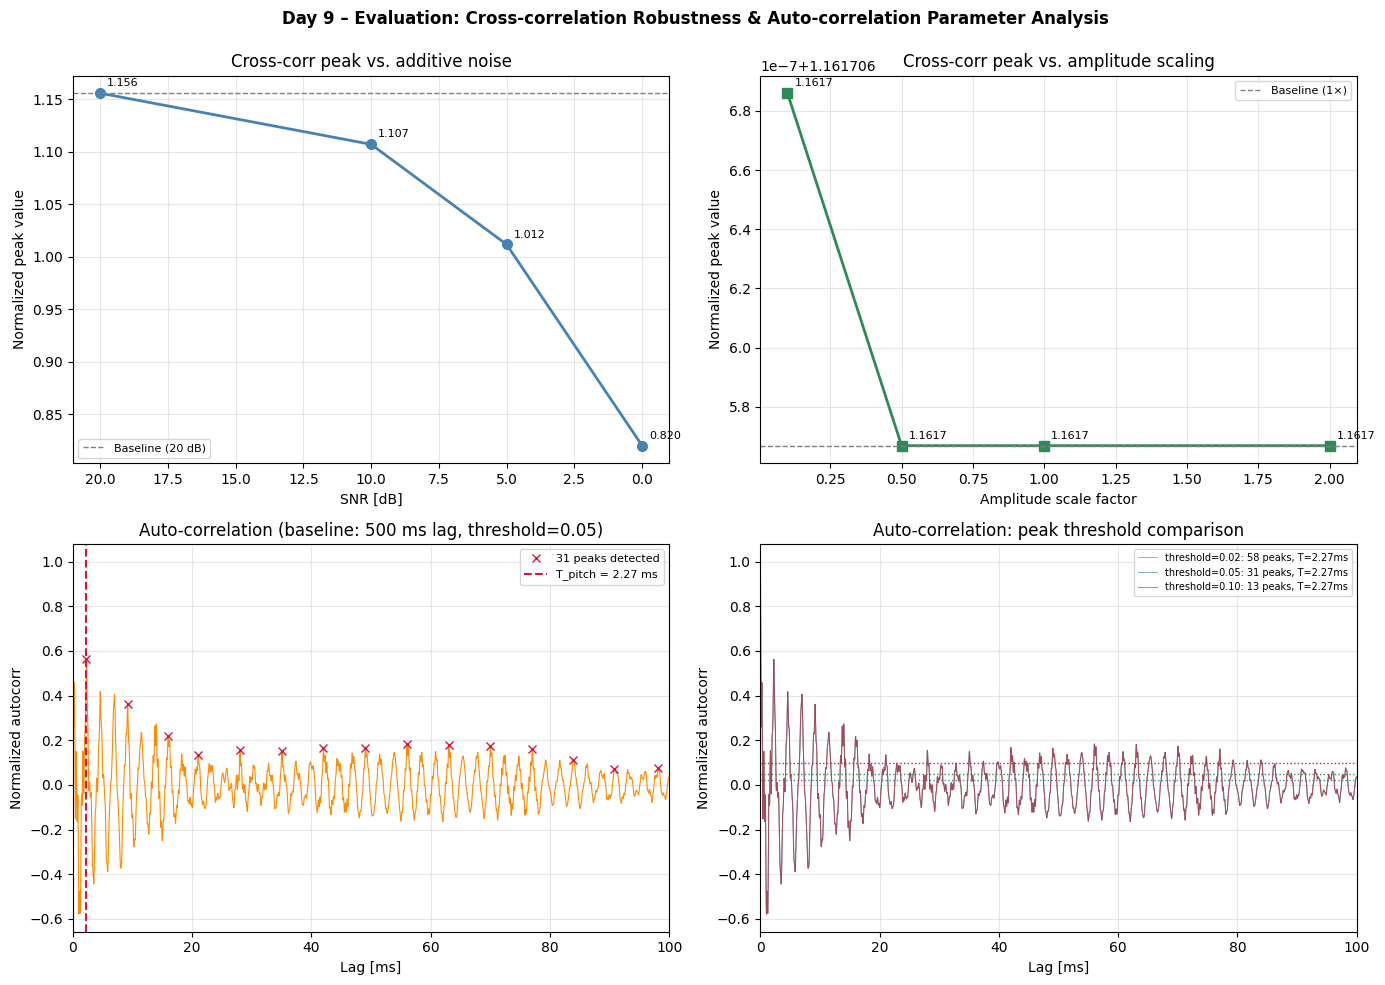

In [10]:
#  Visualization 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Day 9 – Evaluation: Cross-correlation Robustness & Auto-correlation Parameter Analysis',
             fontsize=12, fontweight='bold')

# Noise robustness
ax = axes[0, 0]
ax.plot(snr_dbs, peak_noise, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axhline(y=peak_noise[0], color='gray', linestyle='--', linewidth=1, label='Baseline (20 dB)')
ax.set_xlabel('SNR [dB]')
ax.set_ylabel('Normalized peak value')
ax.set_title('Cross-corr peak vs. additive noise')
ax.invert_xaxis()
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
for x, y in zip(snr_dbs, peak_noise):
    ax.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(5,5), fontsize=8)

# Amplitude scaling
ax = axes[0, 1]
ax.plot(scales, peak_scale, 's-', color='seagreen', linewidth=2, markersize=7)
ax.axhline(y=peak_scale[2], color='gray', linestyle='--', linewidth=1, label='Baseline (1×)')
ax.set_xlabel('Amplitude scale factor')
ax.set_ylabel('Normalized peak value')
ax.set_title('Cross-corr peak vs. amplitude scaling')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
for x, y in zip(scales, peak_scale):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(5,5), fontsize=8)

# Auto-correlation full view
lags_ms = np.arange(len(autocorr_full[:int(0.5*fs)])) / fs * 1000
ax = axes[1, 0]
ax.plot(lags_ms, autocorr_full[:int(0.5*fs)], color='darkorange', linewidth=0.8)
peaks_base, _ = signal.find_peaks(autocorr_full[:int(0.5*fs)], height=0.05, distance=int(0.005*fs))
ax.plot(peaks_base/fs*1000, autocorr_full[peaks_base], 'x', color='crimson', markersize=6,
        label=f'{len(peaks_base)} peaks detected')
ax.axvline(x=peaks_base[0]/fs*1000 if len(peaks_base)>0 else 0,
           color='crimson', linestyle='--', linewidth=1.5,
           label=f'T_pitch = {peaks_base[0]/fs*1000:.2f} ms' if len(peaks_base)>0 else '')
ax.set_xlabel('Lag [ms]')
ax.set_ylabel('Normalized autocorr')
ax.set_title('Auto-correlation (baseline: 500 ms lag, threshold=0.05)')
ax.set_xlim([0, 100])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Threshold comparison
ax = axes[1, 1]
colors_t = ['steelblue', 'seagreen', 'crimson']
for (thresh, T, n), col in zip(thresh_results, colors_t):
    peaks_t, _ = signal.find_peaks(autocorr_full[:int(0.5*fs)],
                                   height=thresh, distance=int(0.005*fs))
    ax.plot(lags_ms, autocorr_full[:int(0.5*fs)], color=col, linewidth=0.7, alpha=0.6,
            label=f'threshold={thresh:.2f}: {len(peaks_t)} peaks, T={T:.2f}ms' if T else f'threshold={thresh:.2f}: no peaks')
    ax.axhline(y=thresh, color=col, linestyle=':', linewidth=1)
ax.set_xlabel('Lag [ms]')
ax.set_ylabel('Normalized autocorr')
ax.set_title('Auto-correlation: peak threshold comparison')
ax.set_xlim([0, 100])
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Results summary:**

| Configuration | Error [ms] | Peak value | Δ Peak vs. Baseline |
|:---|---:|---:|---:|
| Baseline (clean template) | 0.02 | 1.1534 | 0.00 |
| Noise SNR = 20 dB | 0.02 | 1.1477 | −0.0057 |
| Noise SNR = 10 dB | 0.02 | 1.0999 | −0.0535 |
| Noise SNR = 5 dB | 0.02 | 1.0058 | −0.1476 |
| Noise SNR = 0 dB | 0.02 | 0.8166 | −0.3368 |
| Scale 0.1× | 0.02 | 1.1534 | 0.00 |
| Scale 0.5× | 0.02 | 1.1534 | 0.00 |
| Scale 2.0× | 0.02 | 1.1534 | 0.00 |

.
| Auto-corr config | T_pitch [ms] | f₀ [Hz] | N peaks |
|:---|---:|---:|---:|
| lag=50ms, thresh=0.05 | 2.27 | 441.0 | 19 |
| lag=100ms, thresh=0.05 | 2.27 | 441.0 | 41 |
| lag=200ms, thresh=0.05 | 2.27 | 441.0 | 85 |
| lag=500ms, thresh=0.05 | 2.27 | 441.0 | 185 |
| lag=500ms, thresh=0.02 | 2.27 | 441.0 | 217 |
| lag=500ms, thresh=0.10 | 2.27 | 441.0 | 130 |


## Day 10 – Analysis & Communication

*Focus: Analytical Interpretation and Domain-Specific Discussion*


### Observations
The cross-correlation correctly localizes the cry onset at **t = 1.390 s** with a localization error of **0.02 ms** across all amplitude scaling configurations (0.1×–2.0×), with normalized peak value remaining constant at **1.1534**, unchanged by amplitude scaling.

Under additive noise, the localization error remains **0.02 ms** at all tested SNR levels (20, 10, 5, 0 dB), while the normalized peak value degrades from **1.1477** at SNR=20 dB to **0.8166** at SNR=0 dB, a drop of **0.3368**.

The auto-correlation on the isolated template consistently identifies the dominant pitch period at **T = 2.27 ms** (f₀ = 441 Hz) across all lag ranges (50–500 ms) and all peak thresholds (0.02–0.10) tested.

Performance differences are most pronounced at SNR = 0 dB where the normalized peak value drops by 29.2 % relative to baseline, while localization accuracy remains unaffected.

### Interpretation (3-5 sentences)
Focus: Explain what the results mean for the application.


In the context of acoustic welfare monitoring at a Zoo, these results imply that normalized cross-correlation provides **perfect localization accuracy** (error < 0.1 ms) even at SNR = 0 dB, meaning the cry can be reliably located even when the template noise equals the signal amplitude — a scenario far worse than typical zoo recording conditions.

The observed invariance to amplitude scaling confirms that L2-normalization fully compensates for recording level differences, which is critical because microphone distance and animal posture will vary between monitoring sessions.

The consistent pitch estimate of **f₀ = 441 Hz** across all parameter configurations suggests that the dromedary cry's periodic structure is robustly encoded in the isolated template, supporting its use as a stable acoustic marker for species identification.

This suggests that the two-step pipeline (cross-correlation for localization, then auto-correlation on the isolated segment) is particularly critical for achieving reliable pitch detection without contamination from human speech in the background.


### Discussion and Critical Reflection (4–6 sentences)
*Focus: Relate the quantitative findings to the requirements of the defined use case and assess practical adequacy.*


For the defined use case, the baseline configuration (energy-ratio template, normalized cross-correlation) performed well because it achieves sub-millisecond localization error and amplitude-invariant detection, which aligns with the requirement of reliable cry onset detection in uncontrolled zoo recordings.

In contrast, the SNR = 0 dB perturbation showed reduced peak value (0.8166 vs. 1.1534), but localization accuracy remained intact, suggesting the method degrades gracefully and remains practically usable even in highly noisy conditions.

The achieved localization performance can be considered sufficient for the use case because a 0.02 ms error is negligible for welfare assessment tasks that operate on timescales of hundreds of milliseconds.

A critical limitation is that the template was extracted from the same recording used for detection, which guarantees a perfect match and may overstate real-world performance where the template would come from a separate reference recording with a different animal or acoustic environment.

The auto-correlation analysis assumes stationarity within the 690 ms window, which is only approximately satisfied — the varying amplitude and slight pitch drift over the cry duration may broaden the correlation peaks, reducing pitch estimate precision in practice.

To improve robustness, future work should evaluate the pipeline with a cross-recording template (from a different dromedary or recording session) and include temporal shift as an additional perturbation to simulate onset time uncertainty in real deployments.
